In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

# Code for Models

In [16]:
X_train = pd.read_csv('../data/train/X_train.csv')
y_train = pd.read_csv('../data/train/y_train.csv').squeeze()  # Series y_train
X_test = pd.read_csv('../data/test/X_test.csv')
y_test = pd.read_csv('../data/test/y_test.csv').squeeze()      # Series y_test

In [17]:
# Create total_stay: sum of weekend and weekday stays
X_train['total_stay'] = X_train['stays_in_weekend_nights'] + X_train['stays_in_week_nights']
X_test['total_stay'] = X_test['stays_in_weekend_nights'] + X_test['stays_in_week_nights']

# Apply a log transform to lead_time
X_train['lead_time_log'] = np.log1p(X_train['lead_time'])
X_test['lead_time_log'] = np.log1p(X_test['lead_time'])

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train desicion tree model

In [18]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.8496523996984672
Confusion Matrix:
 [[13040  1867]
 [ 1723  7248]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88     14907
           1       0.80      0.81      0.80      8971

    accuracy                           0.85     23878
   macro avg       0.84      0.84      0.84     23878
weighted avg       0.85      0.85      0.85     23878



In [22]:
# Get predicted probabilities for the positive class
y_pred_proba_tree = dt_model.predict_proba(X_test_scaled)[:, 1]

## Train Naive Bayes model

In [20]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.7629198425328755
Confusion Matrix:
 [[12292  2615]
 [ 3046  5925]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81     14907
           1       0.69      0.66      0.68      8971

    accuracy                           0.76     23878
   macro avg       0.75      0.74      0.74     23878
weighted avg       0.76      0.76      0.76     23878



In [21]:
# Get predicted probabilities for the positive class
y_pred_proba_naive = nb_model.predict_proba(X_test_scaled)[:, 1]

## Train logistic model

In [25]:
selected_features = ['lead_time', 'arrival_date_week_number', 'adr', 'hotel_encoded', 'country_encoded', 'room_type_mismatch',
                     'previous_bookings_not_canceled','customer_type_encoded', 'previous_cancellations', 'booking_changes',
                     'required_car_parking_spaces','total_of_special_requests','deposit_encoded',
                     'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined']
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

scaler = StandardScaler()
X_train_reduced_scaled = scaler.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler.transform(X_test_reduced)

# fit the model
logreg_reduced = LogisticRegression()
logreg_reduced.fit(X_train_reduced_scaled, y_train)

y_pred = logreg_reduced.predict(X_test_reduced_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7881313342826032
Confusion Matrix:
 [[13852  1055]
 [ 4004  4967]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.93      0.85     14907
           1       0.82      0.55      0.66      8971

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.75     23878
weighted avg       0.79      0.79      0.78     23878



In [26]:
# Get predicted probabilities for the positive class
y_pred_proba_logistic = logreg_reduced.predict_proba(X_test_reduced_scaled)[:, 1]

# Visualizations

## Model performance comparison

In [2]:
# Data for the models
models = ['Logistic Regression', 'Naïve Bayes', 'Decision Tree']
accuracy = [78.8, 76.1, 85.1]
precision = [82, 70, 80]
recall = [55, 63, 81]
f1_score = [66, 66, 80]

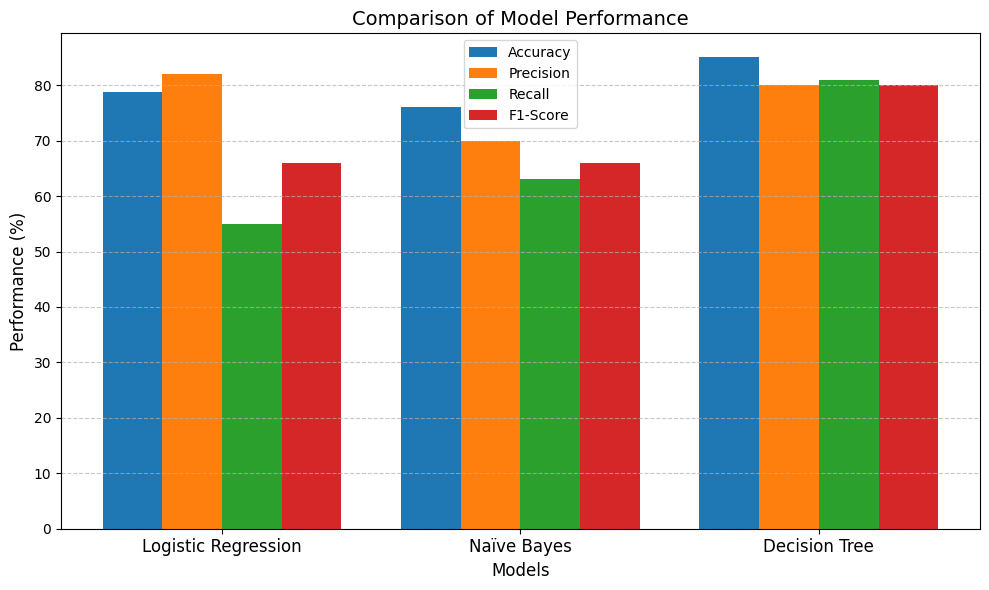

In [3]:
# Grouped bar chart settings
x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Add bars for each metric
ax.bar(x - width, accuracy, width, label='Accuracy')
ax.bar(x, precision, width, label='Precision')
ax.bar(x + width, recall, width, label='Recall')
ax.bar(x + 2 * width, f1_score, width, label='F1-Score')

# Add labels, title, and legend
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_title('Comparison of Model Performance', fontsize=14)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=10)

# Add grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

## Confusion Matrix visualization

In [5]:
# Confusion matrices for each model
confusion_matrices = {
    'Logistic Regression': np.array([[13852, 1055], [4004, 4967]]),
    'Naïve Bayes': np.array([[12526, 2381], [3329, 5642]]),
    'Decision Tree': np.array([[13050, 1857], [1712, 7259]])
}

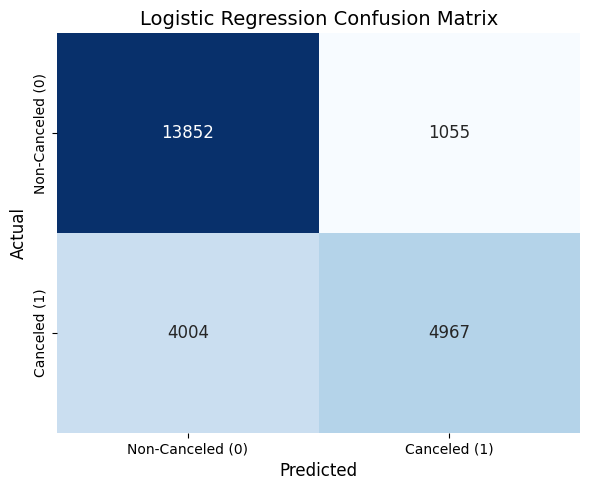

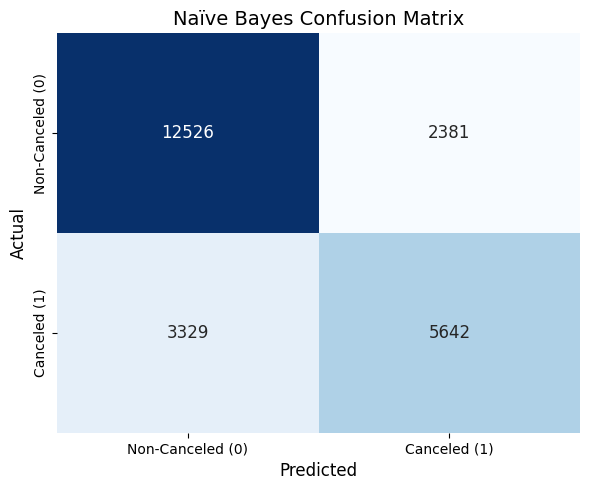

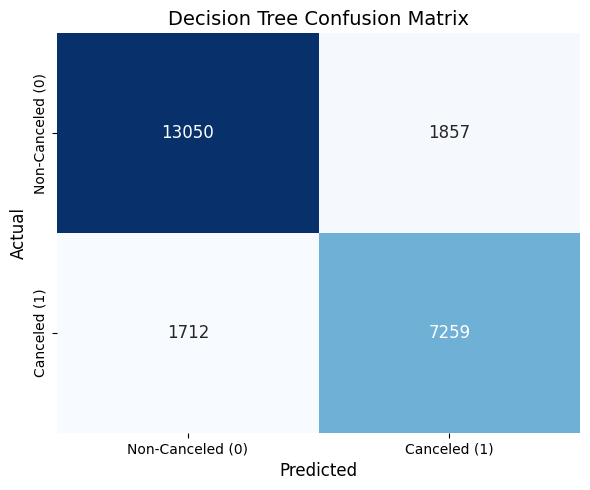

In [7]:
# Function to plot individual confusion matrix heatmap
def plot_confusion_matrix_single(model_name, cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 12})
    plt.title(f'{model_name} Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.xticks([0.5, 1.5], ['Non-Canceled (0)', 'Canceled (1)'], fontsize=10)
    plt.yticks([0.5, 1.5], ['Non-Canceled (0)', 'Canceled (1)'], fontsize=10)
    plt.tight_layout()
    plt.show()

# Plot individual confusion matrices
for model, cm in confusion_matrices.items():
    plot_confusion_matrix_single(model, cm)


## cancellations correlation w/ key attributes

In [8]:
# create dataframe
data = pd.read_csv('../data/processed/log_data_encoded.csv')

## visualize cancellation w/ lead time

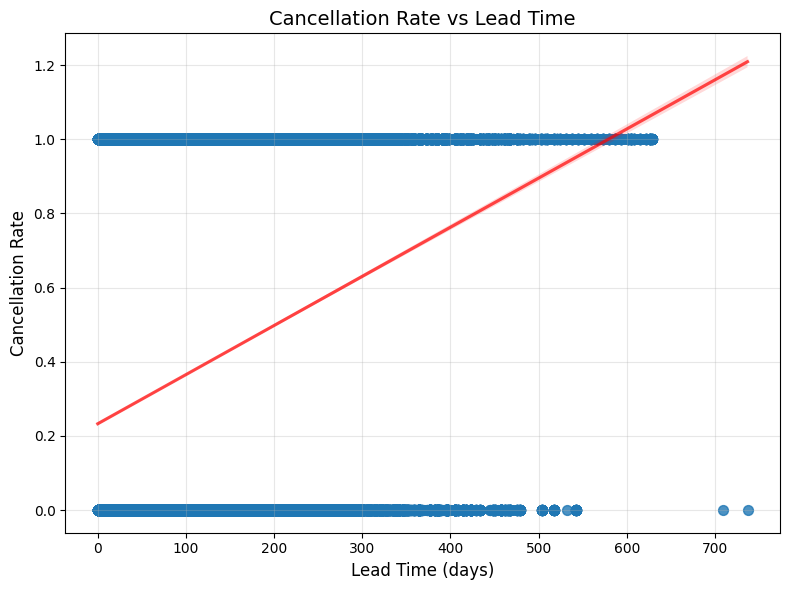

In [10]:
# Define a function to create scatter plots with trendlines
def scatter_with_trendline(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, scatter_kws={"s": 50}, line_kws={"color": "red", "alpha": 0.7})
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Scatter plot: Cancellation rate vs lead time
scatter_with_trendline(
    data['lead_time'],
    data['is_canceled'],
    xlabel='Lead Time (days)',
    ylabel='Cancellation Rate',
    title='Cancellation Rate vs Lead Time'
)


## visualize cancellation w/ adr

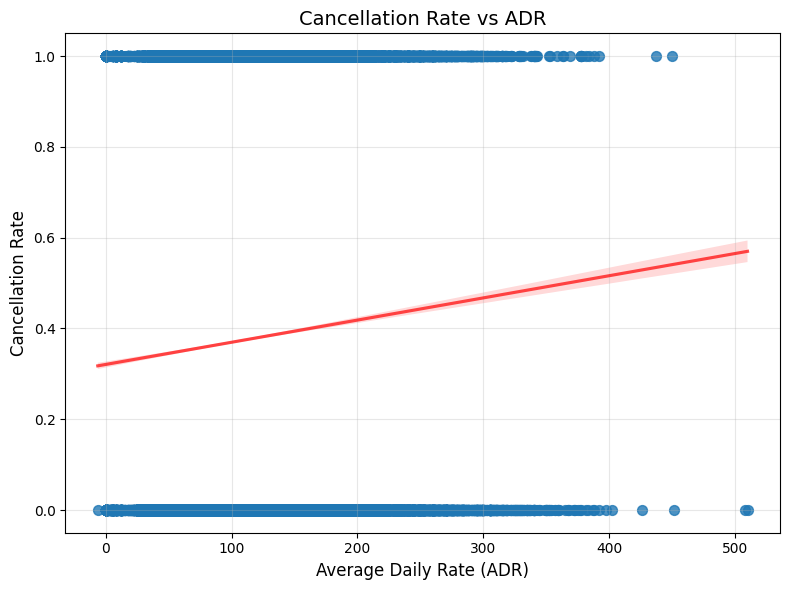

In [32]:
# Scatter plot: Cancellation rate vs adr
scatter_with_trendline(
    data[data['adr']<5000]['adr'],
    data[data['adr']<5000]['is_canceled'],
    xlabel='Average Daily Rate (ADR)',
    ylabel='Cancellation Rate',
    title='Cancellation Rate vs ADR'
)

## visualize cancellation w/ deposit type

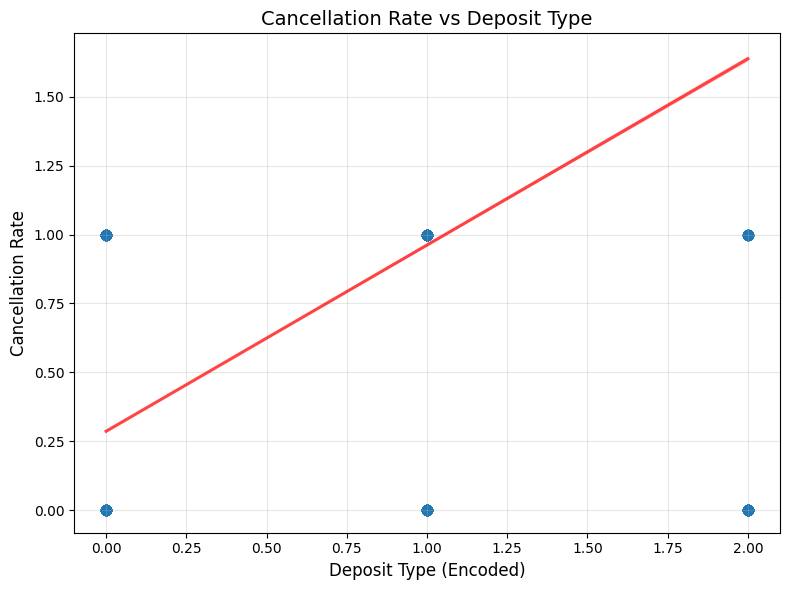

In [12]:
# Scatter plot: Cancellation rate vs deposit_encoded
scatter_with_trendline(
    data['deposit_encoded'],
    data['is_canceled'],
    xlabel='Deposit Type (Encoded)',
    ylabel='Cancellation Rate',
    title='Cancellation Rate vs Deposit Type'
)

## ROC Curves for model comparison

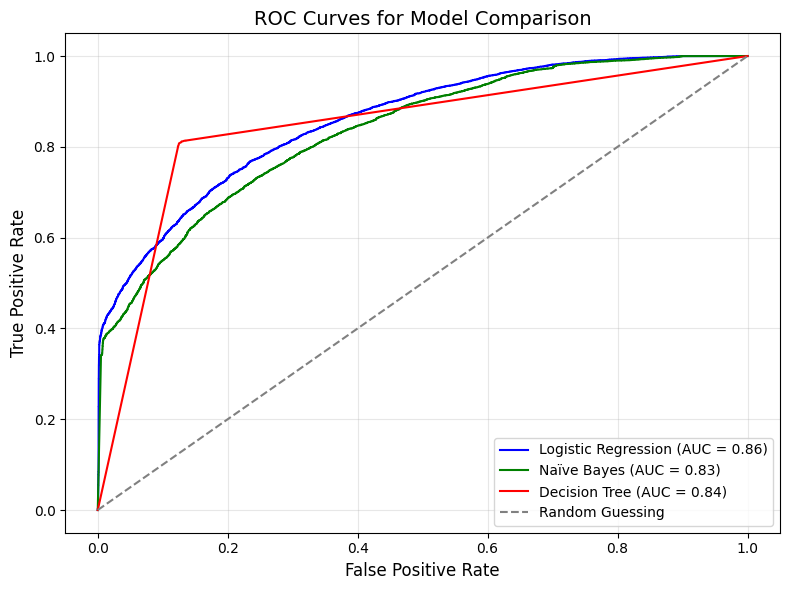

In [27]:
# Calculate ROC curves and AUC scores
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_logistic)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_naive, tpr_naive, _ = roc_curve(y_test, y_pred_proba_naive)
roc_auc_naive = auc(fpr_naive, tpr_naive)

fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_proba_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})', color='blue')
plt.plot(fpr_naive, tpr_naive, label=f'Naïve Bayes (AUC = {roc_auc_naive:.2f})', color='green')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})', color='red')

# Add diagonal line for random guessing
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')

# Add labels, title, and legend
plt.title('ROC Curves for Model Comparison', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()